In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from copy import deepcopy
import warnings

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Introduction to Pruning

Neural network pruning removes redundant parameters to produce smaller, faster models with minimal accuracy loss. The core insight is that modern networks are **heavily over-parameterized** — many weights contribute negligibly to the output. Pruning splits into two fundamentally different paradigms:

| Aspect | Unstructured Pruning | Structured Pruning |
|---|---|---|
| **What is removed** | Individual weights (scalars) | Entire neurons / filters / heads |
| **Resulting sparsity** | Irregular (scattered zeros) | Regular (whole rows/cols removed) |
| **Hardware speedup** | Requires sparse-matrix hardware | Speedup on ANY hardware |
| **Compression** | High compression ratio | Moderate compression ratio |
| **Accuracy impact** | Gentler at same % pruned | Harsher but more practical |

**Sample Input → Output (Conceptual)**
```text
Input: A weight matrix W of shape (hidden_dim, embed_dim)
e.g.
W = [[0.01, -0.9, 0.3],
     [0.8, 0.02, -0.7],
     [-0.05, 0.6, 0.01]]

Unstructured Pruning (50% sparsity):
W_pruned = [[0.0, -0.9, 0.3],
            [0.8, 0.0, -0.7],
            [0.0, 0.6, 0.0]]
→ Individual small-magnitude weights zeroed out. Shape unchanged.

Structured Pruning (remove 1 neuron):
W_pruned = [[-0.9, 0.3],
            [0.02, -0.7],
            [0.6, 0.01]]
→ Entire column (neuron) removed. Shape shrinks from (3,3) to (3,2).
```

In [2]:
class SimpleLM(nn.Module):
    """
    Minimal language model with two feed-forward blocks.
    Serves as the pruning target — all pruning code is external to this class.
    Architecture: Embedding → FFN Block 1 → FFN Block 2 → Output Projection
    Each FFN block: Linear → ReLU → Linear (mimics transformer FFN sublayer)
    """
    def __init__(self, vocab_size=1000, embed_dim=128, hidden_dim=512):
        super().__init__()
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim

        # (num_tokens,) → (num_tokens, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # FFN Block 1: expand then contract, as in transformer FFN
        self.ffn1_up = nn.Linear(embed_dim, hidden_dim)
        self.ffn1_down = nn.Linear(hidden_dim, embed_dim)

        # FFN Block 2: same structure
        self.ffn2_up = nn.Linear(embed_dim, hidden_dim)
        self.ffn2_down = nn.Linear(hidden_dim, embed_dim)

        # Output projection to vocabulary logits
        # (batch_num, seq_len, embed_dim) → (batch_num, seq_len, vocab_size)
        self.output_proj = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        # (batch_num, seq_len) → (batch_num, seq_len, embed_dim)
        h = self.embedding(x)

        # FFN Block 1 with residual connection
        # (batch_num, seq_len, embed_dim)
        residual = h
        h = F.relu(self.ffn1_up(h))
        h = self.ffn1_down(h) + residual

        # FFN Block 2 with residual connection
        # (batch_num, seq_len, embed_dim)
        residual = h
        h = F.relu(self.ffn2_up(h))
        h = self.ffn2_down(h) + residual

        # (batch_num, seq_len, vocab_size)
        logits = self.output_proj(h)
        return logits

# Instantiate the model — this is our pruning subject
model = SimpleLM(vocab_size=1000, embed_dim=128, hidden_dim=512).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model created with {total_params:,} parameters")
print(f"Embed dim: {model.embed_dim}, Hidden dim: {model.hidden_dim}")

# Quick sanity check with dummy input
dummy_input = torch.randint(0, 1000, (2, 16)).to(device)
dummy_output = model(dummy_input)
print(f"Input shape: {tuple(dummy_input.shape)}")
print(f"Output shape: {tuple(dummy_output.shape)}")

Model created with 520,424 parameters
Embed dim: 128, Hidden dim: 512
Input shape: (2, 16)
Output shape: (2, 16, 1000)


# 2) Layer Wise Pruning

## 2.1 Unstructured Pruning

**Intuition**
Unstructured pruning sets individual weight values to zero based on some **importance criterion**. The most common criterion is **magnitude**: small weights contribute little to the output, so removing them causes minimal damage.

Formally, given a weight tensor $W$, we compute a binary mask $M$ of the same shape:

$$M_{ij} = \begin{cases} 1 & \text{if } |W_{ij}| \geq \tau \\ 0 & \text{if } |W_{ij}| < \tau \end{cases}$$

where $\tau$ is the threshold determined by the desired sparsity level $s$. The pruned weight is simply $W' = W \odot M$ (element-wise product).


**Why "Unstructured"?**
* The zeros are **scattered irregularly** throughout the matrix.
* Standard BLAS/GPU kernels cannot skip these zeros — they still multiply by zero and add.
* Speedup requires **sparse matrix formats** (CSR, CSC, block-sparse) and specialized hardware (NVIDIA A100 sparse tensor cores, etc.)

**Sample**

```text
Weight matrix W (hidden_dim=4, embed_dim=3):
[[ 0.01, -0.90,  0.30],
 [ 0.80,  0.02, -0.70],
 [-0.05,  0.60,  0.01],
 [ 0.40, -0.03,  0.50]]

After 50% unstructured pruning (magnitude-based):
Mask M:
[[0, 1, 0],
 [1, 0, 1],
 [0, 1, 0],
 [1, 0, 1]]

Pruned W' = W ⊙ M:
[[ 0.00, -0.90,  0.00],
 [ 0.80,  0.00, -0.70],
 [ 0.00,  0.60,  0.00],
 [ 0.40,  0.00,  0.50]]
→ 6 out of 12 weights zeroed. Shape remains (4, 3). Sparsity = 50%.
```

In [3]:
def unstructured_magnitude_pruning(weight, sparsity):
    """
    Prune individual weights by magnitude.
    Given a weight tensor, compute a binary mask that zeros out the smallest
    `sparsity` fraction of weights by absolute value.

    This is the simplest and most widely-used pruning criterion, justified by
    the observation that small-magnitude weights have small gradient × weight
    products, meaning they contribute little to the loss (Han et al., 2015).

    Args:
        weight: torch.Tensor of any shape (the parameter to prune)
        sparsity: float in [0, 1), fraction of weights to zero out
    Returns:
        mask: binary torch.Tensor of same shape (1 = keep, 0 = prune)
    """

    # Flatten to 1D to find the global magnitude threshold
    # (num_samples,) where num_samples = total elements in weight
    flat_abs = weight.abs().flatten()

    # Compute the threshold: the value below which `sparsity` fraction of weights fall.
    num_to_prune = int(sparsity * flat_abs.numel())

    # Edge case: if sparsity rounds to 0, keep everything
    if num_to_prune == 0:
        return torch.ones_like(weight)

    # The k-th smallest absolute value becomes our cutoff
    threshold = flat_abs.kthvalue(num_to_prune).values.item()

    # Build binary mask: keep weights whose magnitude exceeds threshold
    # (hidden_dim, embed_dim)
    mask = (weight.abs() > threshold).float()
    return mask

def apply_mask(weight, mask):
    """
    Apply a binary pruning mask to a weight tensor via element-wise product.
    This is the fundamental operation: W' = W ⊙ M
    """
    # (hidden_dim, embed_dim)
    return weight * mask

In [4]:
# Demonstrate unstructured pruning on the first FFN up-projection
target_layer = model.ffn1_up
original_weight = target_layer.weight.data.clone()

print(f"Target layer: ffn1_up")
print(f"Weight shape: {tuple(original_weight.shape)}")
print(f"Total parameters: {original_weight.numel():,}")

# Prune at multiple sparsity levels to see the progression
sparsity_levels = [0.0, 0.3, 0.5, 0.7, 0.9]
masks_unstruct = {}

for s in sparsity_levels:
    mask = unstructured_magnitude_pruning(original_weight, s)
    pruned_w = apply_mask(original_weight, mask)

    actual_sparsity = 1.0 - mask.sum().item() / mask.numel()
    nonzero = mask.sum().item()
    masks_unstruct[s] = mask

    print(f"\nSparsity target: {s:.0%}")
    print(f"  Actual sparsity: {actual_sparsity:.2%}")
    print(f"  Non-zero weights: {int(nonzero):,} / {mask.numel():,}")
    print(f"  Weight shape (unchanged): {tuple(pruned_w.shape)}")

Target layer: ffn1_up
Weight shape: (512, 128)
Total parameters: 65,536

Sparsity target: 0%
  Actual sparsity: 0.00%
  Non-zero weights: 65,536 / 65,536
  Weight shape (unchanged): (512, 128)

Sparsity target: 30%
  Actual sparsity: 30.00%
  Non-zero weights: 45,876 / 65,536
  Weight shape (unchanged): (512, 128)

Sparsity target: 50%
  Actual sparsity: 50.00%
  Non-zero weights: 32,768 / 65,536
  Weight shape (unchanged): (512, 128)

Sparsity target: 70%
  Actual sparsity: 70.00%
  Non-zero weights: 19,661 / 65,536
  Weight shape (unchanged): (512, 128)

Sparsity target: 90%
  Actual sparsity: 90.00%
  Non-zero weights: 6,554 / 65,536
  Weight shape (unchanged): (512, 128)


## 2.2 Structured Pruning

**Intuition**
Structured pruning removes **entire structural units**: neurons, filters, attention heads, or even whole layers. Instead of zeroing individual weights, we remove entire rows or columns from weight matrices.

For a linear layer $y = Wx + b$ where $W \in \mathbb{R}^{d_{out} \times d_{in}}$:
- **Pruning an output neuron** removes an entire **row** of $W$ and the corresponding entry in $b$. The output dimension shrinks.
- **Pruning an input neuron** removes an entire **column** of $W$ (and the corresponding row in the next layer's weight matrix).

---

**Why "Structured"?**
The result is a **genuinely smaller dense matrix**. No sparse formats needed — standard GEMM operations run faster simply because the matrix is smaller. This is the main practical advantage.

**Importance Criteria for Neurons**
How do we decide which neuron to remove? Common criteria:

1. **L1-norm of weights** (Li et al., 2017):
   $\text{importance}(j) = \sum_i |W_{j,i}|$
   Neurons with small total weight magnitude are deemed unimportant.

2. **L2-norm of weights**:
   $\text{importance}(j) = \sqrt{\sum_i W_{j,i}^2}$
   Similar intuition, but penalizes large outliers less.

3. **Taylor expansion** (Molchanov et al., 2019):
   $\text{importance}(j) = |W_j \cdot \nabla_{W_j} \mathcal{L}|$
   Approximates the change in loss when neuron $j$ is removed. More principled but requires gradient information.

---

**Sample**
```text
W shape: (hidden_dim=4, embed_dim=3)
[[ 0.01, -0.90,  0.30],  ← neuron 0, L1-norm = 1.21
 [ 0.80,  0.02, -0.70],  ← neuron 1, L1-norm = 1.52
 [-0.05,  0.60,  0.01],  ← neuron 2, L1-norm = 0.66  ← SMALLEST
 [ 0.40, -0.03,  0.50]]  ← neuron 3, L1-norm = 0.93

After structured pruning (remove 1 neuron by L1-norm):
→ Remove neuron 2 (smallest L1-norm = 0.66)

W_pruned shape: (3, 3) ← dimension actually shrinks!
[[ 0.01, -0.90,  0.30],
 [ 0.80,  0.02, -0.70],
 [ 0.40, -0.03,  0.50]]

b_pruned shape: (3,)   ← bias also shrinks

→ The network is genuinely smaller. No masks needed.
```

In [6]:
def compute_neuron_importance_l1(weight):
    """
    Compute importance of each output neuron using L1-norm of its weights.
    For W of shape (output_dim, input_dim), each row corresponds to one output neuron.
    The L1-norm sums the absolute values of all incoming weights to that neuron.
    A small L1-norm means the neuron's output contributes little.

    Args:
        weight: (output_dim, input_dim) weight tensor
    Returns:
        importance: (output_dim,) tensor of L1-norm importance scores
    """
    # Sum absolute values along the input dimension (dim=1)
    # (output_dim, input_dim) → (output_dim,)
    importance = weight.abs().sum(dim=1)
    return importance

def compute_neuron_importance_l2(weight):
    """
    Compute importance of each output neuron using L2-norm of its weights.
    Similar to L1 but uses Euclidean norm.
    L2-norm is less sensitive to a single large weight (more "democratic" across inputs).

    Args:
        weight: (output_dim, input_dim) weight tensor
    Returns:
        importance: (output_dim,) tensor of L2-norm importance scores
    """
    # Euclidean norm along the input dimension
    # (output_dim, input_dim) → (output_dim,)
    importance = weight.norm(p=2, dim=1)
    return importance

def structured_pruning_neurons(weight, bias, sparsity, importance_fn):
    """
    Remove entire output neurons from a linear layer.
    Given desired sparsity (fraction of neurons to remove), compute importance scores,
    identify the least important neurons, and physically remove their rows from the
    weight matrix and entries from the bias vector.

    CRITICAL DIFFERENCE from unstructured pruning:
    - Unstructured: returns a mask, shape unchanged, zeros scattered
    - Structured: returns SMALLER tensors, no mask needed

    Args:
        weight: (output_dim, input_dim) weight tensor
        bias: (output_dim,) bias tensor (or None)
        sparsity: float in [0, 1), fraction of neurons to remove
        importance_fn: callable that takes weight → (output_dim,) importance
    Returns:
        pruned_weight: (output_dim - num_pruned, input_dim) — actually smaller!
        pruned_bias: (output_dim - num_pruned,) or None
        keep_indices: 1D tensor of indices of surviving neurons
    """
    output_dim = weight.shape[0]

    # Compute per-neuron importance scores
    # (output_dim,)
    importance = importance_fn(weight)

    # Determine how many neurons to remove
    num_to_prune = int(sparsity * output_dim)
    num_to_keep = output_dim - num_to_prune

    # argsort importance in descending order; keep the top-k most important
    # (output_dim,) → (output_dim,)
    sorted_indices = importance.argsort(descending=True)
    keep_indices = sorted_indices[:num_to_keep].sort().values

    # Select only the surviving rows from the weight matrix
    # (output_dim, input_dim) → (num_to_keep, input_dim)
    pruned_weight = weight[keep_indices]

    # Select corresponding bias entries
    # (output_dim,) → (num_to_keep,)
    pruned_bias = bias[keep_indices] if bias is not None else None

    return pruned_weight, pruned_bias, keep_indices

In [7]:
# Demonstrate structured pruning on ffn1_up
original_weight = model.ffn1_up.weight.data.clone()
original_bias = model.ffn1_up.bias.data.clone()

print(f"Original weight shape: {tuple(original_weight.shape)}")
print(f"Original bias shape: {tuple(original_bias.shape)}")
print(f"Original parameters: {original_weight.numel() + original_bias.numel():,}")

sparsity_levels_struct = [0.25, 0.50, 0.75]

for s in sparsity_levels_struct:
    pw, pb, keep_idx = structured_pruning_neurons(
        original_weight, original_bias, s, compute_neuron_importance_l1
    )

    param_count = pw.numel() + (pb.numel() if pb is not None else 0)

    print(f"\nStructured pruning at {s:.0%} neuron removal:")
    print(f"  Pruned weight shape: {tuple(pw.shape)} ← dimension shrinks!")
    print(f"  Pruned bias shape: {tuple(pb.shape)}")
    print(f"  Parameters: {param_count:,} (was {original_weight.numel() + original_bias.numel():,})")
    print(f"  Kept {len(keep_idx)} / {original_weight.shape[0]} neurons")

Original weight shape: (512, 128)
Original bias shape: (512,)
Original parameters: 66,048

Structured pruning at 25% neuron removal:
  Pruned weight shape: (384, 128) ← dimension shrinks!
  Pruned bias shape: (384,)
  Parameters: 49,536 (was 66,048)
  Kept 384 / 512 neurons

Structured pruning at 50% neuron removal:
  Pruned weight shape: (256, 128) ← dimension shrinks!
  Pruned bias shape: (256,)
  Parameters: 33,024 (was 66,048)
  Kept 256 / 512 neurons

Structured pruning at 75% neuron removal:
  Pruned weight shape: (128, 128) ← dimension shrinks!
  Pruned bias shape: (128,)
  Parameters: 16,512 (was 66,048)
  Kept 128 / 512 neurons


# 3) Global Pruning

**Intuition**
So far we pruned each layer independently at the same sparsity level. But different layers have different **sensitivity** to pruning — early layers and the final classifier are often more sensitive.

**Layer-wise (uniform) pruning**:
- Each layer gets the same sparsity target.
- Simple but suboptimal — it may aggressively prune sensitive layers while under-pruning redundant ones.

**Global pruning**:
- Pool ALL weights across the network, compute a single global threshold, and apply it everywhere.
- Layers with naturally larger weights keep more parameters; layers with smaller weights get pruned harder.
- This tends to allocate the pruning budget more efficiently because it respects the natural importance distribution across layers.

**Sample Input**
```
Layer A weights (small magnitudes): [0.01, 0.02, 0.03, 0.04]
Layer B weights (large magnitudes): [0.50, 0.60, 0.70, 0.80]

Global 50% pruning (4 of 8 total weights removed):
Global threshold ≈ 0.04
Layer A: [0.00, 0.00, 0.00, 0.04] → 75% pruned (more sensitive = pruned harder)
Layer B: [0.50, 0.60, 0.70, 0.80] → 0% pruned (important = preserved)

Uniform 50% pruning (2 of 4 per layer):
Layer A: [0.00, 0.00, 0.03, 0.04] → 50% pruned
Layer B: [0.00, 0.00, 0.70, 0.80] → 50% pruned (unnecessarily aggressive!)
```

## 3.1 Unstructured Pruning

In [9]:
def global_unstructured_pruning(named_params, sparsity):
    """
    Pool all weight magnitudes across the entire model and apply a single global threshold.
    This automatically allocates pruning budget: layers with smaller weights get pruned more,
    layers with larger weights less.

    Args:
        named_params: list of (name, weight_tensor) tuples to prune
        sparsity: float in [0, 1), overall fraction of weights to remove
    Returns:
        masks: dict mapping name → binary mask tensor
        threshold: the global magnitude cutoff value
    """
    # Concatenate all weight magnitudes into one flat vector
    all_magnitudes = torch.cat([w.abs().flatten() for _, w in named_params])
    total_params = all_magnitudes.numel()

    # Find the global threshold at the desired sparsity percentile
    num_to_prune = int(sparsity * total_params)
    if num_to_prune == 0:
        return {name: torch.ones_like(w) for name, w in named_params}, 0.0

    # (total_params,) → scalar
    threshold = all_magnitudes.kthvalue(num_to_prune).values.item()

    # Apply the same threshold to every layer
    masks = {}
    for name, w in named_params:
        # Each mask has the same shape as its corresponding weight
        masks[name] = (w.abs() > threshold).float()

    return masks, threshold

# Collect all prunable weight matrices (skip embedding and biases)
prunable_layers = [
    ("ffn1_up", model.ffn1_up.weight.data),
    ("ffn1_down", model.ffn1_down.weight.data),
    ("ffn2_up", model.ffn2_up.weight.data),
    ("ffn2_down", model.ffn2_down.weight.data),
    ("output_proj", model.output_proj.weight.data),
]

# Global pruning at 50%
global_masks, global_threshold = global_unstructured_pruning(prunable_layers, 0.5)
print(f"Global threshold: {global_threshold:.6f}\n")

# Compare per-layer sparsity under global vs uniform pruning
print(f"{'Layer':<15} {'Shape':<16} {'Global Sparsity':>16} {'Uniform Sparsity':>17}")
print("-" * 68)

for name, w in prunable_layers:
    # Global: each layer gets different sparsity based on its magnitude distribution
    g_mask = global_masks[name]
    g_sparsity = 1.0 - g_mask.sum().item() / g_mask.numel()

    # Uniform: force 50% on every layer independently
    u_mask = unstructured_magnitude_pruning(w, 0.5)
    u_sparsity = 1.0 - u_mask.sum().item() / u_mask.numel()

    print(f"{name:<15} {str(tuple(w.shape)):<16} {g_sparsity:>15.2%} {u_sparsity:>16.2%}")

Global threshold: 0.033128

Layer           Shape             Global Sparsity  Uniform Sparsity
--------------------------------------------------------------------
ffn1_up         (512, 128)                37.74%           50.00%
ffn1_down       (128, 512)                74.84%           50.00%
ffn2_up         (512, 128)                37.36%           50.00%
ffn2_down       (128, 512)                74.77%           50.00%
output_proj     (1000, 128)               37.34%           50.00%


## 3.1 The Coupling Problem

**The Coupling Problem**

In feed-forward networks, pruning output neurons from layer $l$ means we must also prune the **corresponding input columns** from layer $l+1$. This is because removing neuron $j$ from layer $l$ means the $j$-th output no longer exists, so the $j$-th input to the next layer is gone.

```
FFN Block: x → [ffn_up: (embed_dim → hidden_dim)] → ReLU → [ffn_down: (hidden_dim → embed_dim)]

If we prune neuron j from ffn_up:
- Remove row j from ffn_up.weight (output neuron j is gone)
- Remove entry j from ffn_up.bias
- Remove column j from ffn_down.weight (input j to ffn_down is gone)

→ Both layers shrink consistently!
```

This **coupling** between adjacent layers is what makes structured pruning non-trivial in practice. You must propagate the structural change through the dependency graph.

In [11]:
def prune_ffn_block_structured(up_weight, up_bias, down_weight, down_bias, sparsity, importance_fn):
    """
    Prune an entire FFN block (up-projection + down-projection) in a COUPLED manner.
    Removing hidden neurons from the up-projection requires removing the corresponding
    input columns from the down-projection.

    This is the correct way to do structured pruning on paired layers.
    Pruning them independently would create shape mismatches.

    Architecture:
    up: (embed_dim) → (hidden_dim)          W_up is (hidden_dim, embed_dim)
    down: (hidden_dim) → (embed_dim)        W_down is (embed_dim, hidden_dim)

    After pruning k neurons:
    up: (embed_dim) → (hidden_dim - k)      W_up is (hidden_dim-k, embed_dim)
    down: (hidden_dim - k) → (embed_dim)    W_down is (embed_dim, hidden_dim-k)

    Args:
        up_weight: (hidden_dim, embed_dim) up-projection weights
        up_bias: (hidden_dim,) up-projection bias
        down_weight: (embed_dim, hidden_dim) down-projection weights
        down_bias: (embed_dim,) down-projection bias
        sparsity: fraction of hidden neurons to remove
        importance_fn: callable for neuron importance scores
    Returns:
        Tuple of (pruned_up_weight, pruned_up_bias, pruned_down_weight, pruned_down_bias, keep_indices)
    """
    # Compute importance based on the up-projection output neurons (rows)
    # (hidden_dim,)
    importance = importance_fn(up_weight)

    hidden_dim = up_weight.shape[0]
    num_to_prune = int(sparsity * hidden_dim)
    num_to_keep = hidden_dim - num_to_prune

    # Select the most important neurons to keep
    # (hidden_dim,) → (num_to_keep,)
    keep_indices = importance.argsort(descending=True)[:num_to_keep].sort().values

    # Prune up-projection: remove rows (output neurons)
    # (hidden_dim, embed_dim) → (num_to_keep, embed_dim)
    pruned_up_weight = up_weight[keep_indices]
    # (hidden_dim,) → (num_to_keep,)
    pruned_up_bias = up_bias[keep_indices] if up_bias is not None else None

    # Prune down-projection: remove COLUMNS (input features that no longer exist)
    # (embed_dim, hidden_dim) → (embed_dim, num_to_keep)
    pruned_down_weight = down_weight[:, keep_indices]
    # Bias of down-projection is NOT affected (it corresponds to output dim = embed_dim)
    pruned_down_bias = down_bias

    return (pruned_up_weight, pruned_up_bias, pruned_down_weight, pruned_down_bias, keep_indices)

# Demonstrate coupled pruning on FFN Block 1
up_w = model.ffn1_up.weight.data.clone()
up_b = model.ffn1_up.bias.data.clone()
down_w = model.ffn1_down.weight.data.clone()
down_b = model.ffn1_down.bias.data.clone()

print("Before coupled structured pruning:")
print(f"  ffn1_up weight: {tuple(up_w.shape)}")
print(f"  ffn1_down weight: {tuple(down_w.shape)}")
print(f"  Hidden dim: {up_w.shape[0]}")

for s in [0.25, 0.50, 0.75]:
    p_up_w, p_up_b, p_down_w, p_down_b, keep = prune_ffn_block_structured(
        up_w, up_b, down_w, down_b, s, compute_neuron_importance_l1
    )

    print(f"\nAfter {s:.0%} neuron pruning:")
    print(f"  ffn1_up weight: {tuple(p_up_w.shape)} (rows removed)")
    print(f"  ffn1_down weight: {tuple(p_down_w.shape)} (columns removed)")
    print(f"  Hidden dim: {p_up_w.shape[0]} (was {up_w.shape[0]})")

    # Verify shapes are compatible for forward pass
    dummy = torch.randn(1, 16, 128).to(device)
    h = F.relu(F.linear(dummy, p_up_w, p_up_b))
    out = F.linear(h, p_down_w, p_down_b)
    print(f"  Forward pass: {tuple(dummy.shape)} → {tuple(h.shape)} → {tuple(out.shape)} ✓")

Before coupled structured pruning:
  ffn1_up weight: (512, 128)
  ffn1_down weight: (128, 512)
  Hidden dim: 512

After 25% neuron pruning:
  ffn1_up weight: (384, 128) (rows removed)
  ffn1_down weight: (128, 384) (columns removed)
  Hidden dim: 384 (was 512)
  Forward pass: (1, 16, 128) → (1, 16, 384) → (1, 16, 128) ✓

After 50% neuron pruning:
  ffn1_up weight: (256, 128) (rows removed)
  ffn1_down weight: (128, 256) (columns removed)
  Hidden dim: 256 (was 512)
  Forward pass: (1, 16, 128) → (1, 16, 256) → (1, 16, 128) ✓

After 75% neuron pruning:
  ffn1_up weight: (128, 128) (rows removed)
  ffn1_down weight: (128, 128) (columns removed)
  Hidden dim: 128 (was 512)
  Forward pass: (1, 16, 128) → (1, 16, 128) → (1, 16, 128) ✓


# 4) Analysis

## 4.1 Importance Criteria — Comparison

Different pruning criteria can lead to very different decisions about which neurons to keep.

Let's compare L1-norm, L2-norm, and a random baseline on the same layer.

**Why This Matters**
The choice of importance metric is a **design decision** with real consequences:
- L1-norm favors neurons where weights are spread across many inputs
- L2-norm favors neurons with at least one large weight
- Random pruning provides a lower bound on performance

In practice, magnitude-based criteria work surprisingly well for feedforward layers (Han et al., 2015), but more sophisticated criteria (Taylor expansion, Fisher information) become important for attention heads and other structures (Michel et al., 2019 — *Are Sixteen Heads Really Better than One?*).

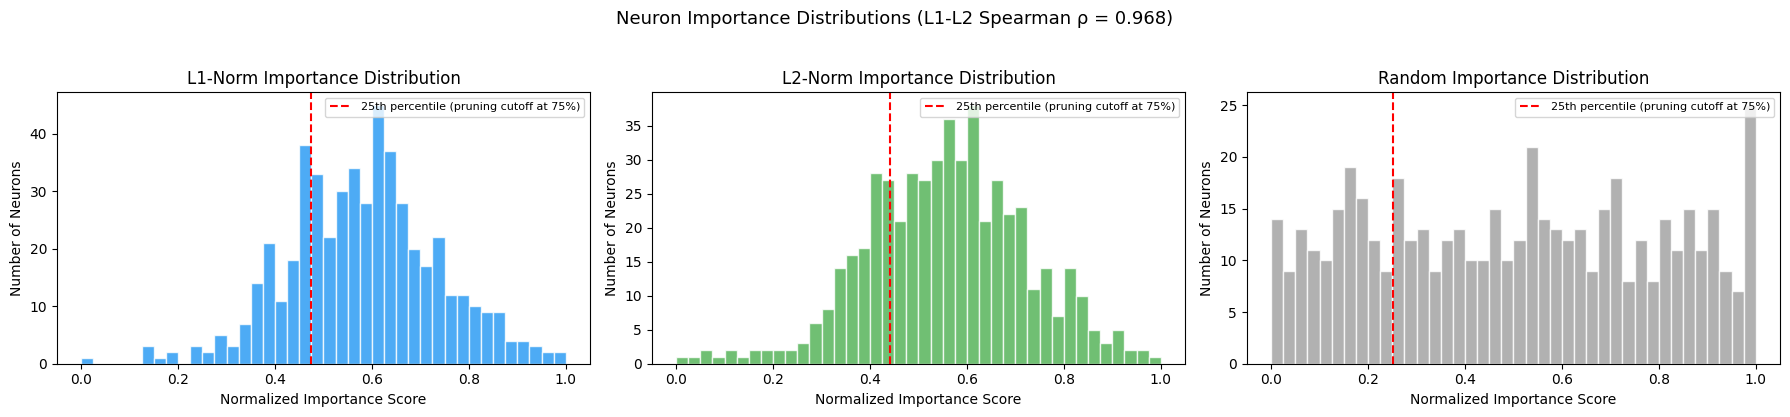

In [24]:
def compute_neuron_importance_random(weight):
    """
    Random importance baseline. Each neuron gets a random score.
    This serves as a sanity check — any reasonable criterion should outperform random selection.
    """
    # (output_dim,)
    return torch.rand(weight.shape[0], device=weight.device)

# Compute importance scores for ffn1_up
weight = model.ffn1_up.weight.data
l1_scores = compute_neuron_importance_l1(weight)
l2_scores = compute_neuron_importance_l2(weight)
random_scores = compute_neuron_importance_random(weight)

# Normalize all scores to [0, 1] for comparison
def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

l1_norm = normalize(l1_scores).cpu().numpy()
l2_norm = normalize(l2_scores).cpu().numpy()
random_norm = normalize(random_scores).cpu().numpy()

# Rank correlation between L1 and L2
from scipy.stats import spearmanr
corr, pval = spearmanr(l1_norm, l2_norm)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histogram of importance scores
for ax, scores, name, color in zip(
    axes,
    [l1_norm, l2_norm, random_norm],
    ["L1-Norm", "L2-Norm", "Random"],
    ["#2196F3", "#4CAF50", "#9E9E9E"]
):
    ax.hist(scores, bins=40, color=color, alpha=0.8, edgecolor="white")
    ax.set_title(f"{name} Importance Distribution", fontsize=12)
    ax.set_xlabel("Normalized Importance Score")
    ax.set_ylabel("Number of Neurons")
    ax.axvline(
        np.percentile(scores, 25),
        color="red",
        linestyle="--",
        label="25th percentile (pruning cutoff at 75%)"
    )
    ax.legend(fontsize=8)

plt.suptitle(f"Neuron Importance Distributions (L1-L2 Spearman ρ = {corr:.3f})", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 4.2 Output Impact Analysis

The ultimate question: **how does pruning affect the model's output?**

We measure this by comparing the logits (output distribution) of the original model versus pruned versions. We use:
- **Cosine similarity** between output logit vectors (1.0 = identical)
- **KL divergence** between output probability distributions (0.0 = identical)

This gives us a direct, task-independent measure of pruning damage.

In [23]:
def measure_output_divergence(model_orig, model_pruned, input_ids):
    """
    Compare two models' outputs on the same input.
    Metrics:
    - Cosine similarity of raw logits (geometric alignment)
    - KL divergence of softmax distributions (information-theoretic)

    Args:
        model_orig: original unpruned model
        model_pruned: pruned model (may have different internal dimensions)
        input_ids: (batch_num, seq_len) input tensor
    Returns:
        cos_sim: mean cosine similarity across all positions
        kl_div: mean KL divergence across all positions
    """
    with torch.no_grad():
        # (batch_num, seq_len, vocab_size)
        logits_orig = model_orig(input_ids)
        logits_pruned = model_pruned(input_ids)

        # Flatten to (batch_num * seq_len, vocab_size) for comparison
        lo = logits_orig.reshape(-1, logits_orig.shape[-1])
        lp = logits_pruned.reshape(-1, logits_pruned.shape[-1])

        # Cosine similarity: how aligned are the logit vectors?
        # (num_samples, vocab_size) × (num_samples, vocab_size) → (num_samples,)
        cos_sim = F.cosine_similarity(lo, lp, dim=-1).mean().item()

        # KL divergence: how different are the probability distributions?
        # (num_samples, vocab_size) → scalar
        log_probs_orig = F.log_softmax(lo, dim=-1)
        probs_pruned = F.softmax(lp, dim=-1)
        kl = F.kl_div(
            F.log_softmax(lp, dim=-1),
            F.softmax(lo, dim=-1),
            reduction="batchmean"
        ).item()

        return cos_sim, kl

# Generate random input for evaluation
eval_input = torch.randint(0, 1000, (4, 32)).to(device)

# Test unstructured pruning at various sparsities
print("=" * 65)
print("UNSTRUCTURED PRUNING — Output Impact")
print("=" * 65)
print(f"{'Sparsity':>10} {'Cosine Sim':>12} {'KL Divergence':>15}")
print("-" * 40)

for s in [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95]:
    # Create a pruned copy of the model
    model_copy = deepcopy(model)

    # Apply unstructured pruning to all FFN layers
    for name in ["ffn1_up", "ffn1_down", "ffn2_up", "ffn2_down"]:
        layer = getattr(model_copy, name)
        mask = unstructured_magnitude_pruning(layer.weight.data, s)
        layer.weight.data = apply_mask(layer.weight.data, mask)

    cos_sim, kl_div = measure_output_divergence(model, model_copy, eval_input)
    print(f"{s:>9.0%} {cos_sim:>12.6f} {kl_div:>15.6f}")

UNSTRUCTURED PRUNING — Output Impact
  Sparsity   Cosine Sim   KL Divergence
----------------------------------------
       0%     1.000000        0.000000
      10%     0.999898        0.000039
      30%     0.997433        0.000978
      50%     0.988579        0.004316
      70%     0.972421        0.010371
      90%     0.954798        0.016764
      95%     0.952034        0.017773


In [14]:
# Test structured pruning at various levels
print("=" * 65)
print("STRUCTURED PRUNING — Output Impact")
print("=" * 65)
print(f"{'Neurons Pruned':>15} {'Hidden Dim':>12} {'Cosine Sim':>12} {'KL Divergence':>15}")
print("-" * 58)

for s in [0.0, 0.1, 0.25, 0.5, 0.75, 0.9]:
    model_copy = deepcopy(model)

    # Prune both FFN blocks in a coupled manner
    for block_name in ["ffn1", "ffn2"]:
        up_layer = getattr(model_copy, f"{block_name}_up")
        down_layer = getattr(model_copy, f"{block_name}_down")

        p_up_w, p_up_b, p_down_w, p_down_b, _ = prune_ffn_block_structured(
            up_layer.weight.data, up_layer.bias.data,
            down_layer.weight.data, down_layer.bias.data,
            s, compute_neuron_importance_l1
        )

        # Replace the layers with smaller ones
        new_hidden = p_up_w.shape[0]
        new_up = nn.Linear(model.embed_dim, new_hidden).to(device)
        new_down = nn.Linear(new_hidden, model.embed_dim).to(device)

        new_up.weight.data = p_up_w
        new_up.bias.data = p_up_b
        new_down.weight.data = p_down_w
        new_down.bias.data = p_down_b

        setattr(model_copy, f"{block_name}_up", new_up)
        setattr(model_copy, f"{block_name}_down", new_down)

    cos_sim, kl_div = measure_output_divergence(model, model_copy, eval_input)
    new_h = model_copy.ffn1_up.weight.shape[0]
    print(f"{s:>14.0%} {new_h:>12} {cos_sim:>12.6f} {kl_div:>15.6f}")

STRUCTURED PRUNING — Output Impact
 Neurons Pruned   Hidden Dim   Cosine Sim   KL Divergence
----------------------------------------------------------
            0%          512     1.000000       -0.000000
           10%          461     0.995266        0.001752
           25%          384     0.987722        0.004486
           50%          256     0.974771        0.009178
           75%          128     0.962123        0.013654
           90%           52     0.955652        0.015966


## 4.3 Weight Distribution Analysis

- Pruning effectiveness depends on the **weight distribution**.
- If weights are concentrated near zero (as is common after training), magnitude-based pruning can remove many weights with little impact.
- If weights are uniformly spread, pruning is more damaging.

Here we visualize how the weight distribution changes before and after pruning, and why this matters.

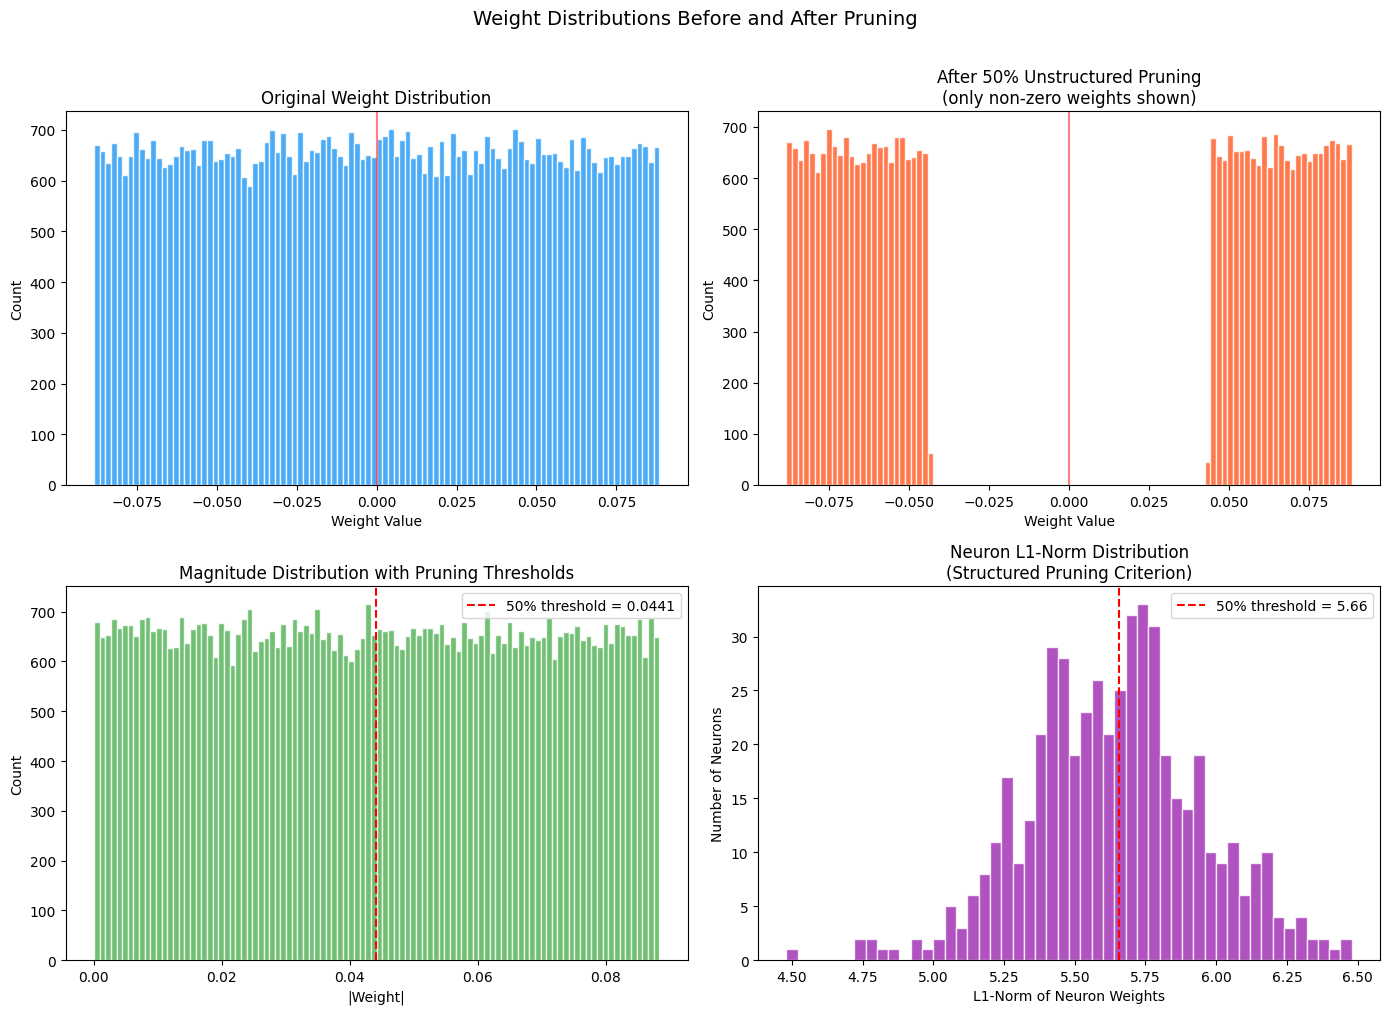

In [15]:
weight = model.ffn1_up.weight.data.clone()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: original weight distribution
vals = weight.flatten().cpu().numpy()
axes[0, 0].hist(vals, bins=100, color="#2196F3", alpha=0.8, edgecolor="white")
axes[0, 0].set_title("Original Weight Distribution", fontsize=12)
axes[0, 0].set_xlabel("Weight Value")
axes[0, 0].set_ylabel("Count")
axes[0, 0].axvline(0, color="red", linestyle="-", alpha=0.5)

# Top-right: after 50% unstructured pruning
mask = unstructured_magnitude_pruning(weight, 0.5)
pruned = apply_mask(weight, mask)
vals_p = pruned.flatten().cpu().numpy()
nonzero_vals = vals_p[vals_p != 0]
axes[0, 1].hist(nonzero_vals, bins=100, color="#FF5722", alpha=0.8, edgecolor="white")
axes[0, 1].set_title("After 50% Unstructured Pruning\n(only non-zero weights shown)", fontsize=12)
axes[0, 1].set_xlabel("Weight Value")
axes[0, 1].set_ylabel("Count")
axes[0, 1].axvline(0, color="red", linestyle="-", alpha=0.5)

# Bottom-left: magnitude distribution (absolute values)
axes[1, 0].hist(np.abs(vals), bins=100, color="#4CAF50", alpha=0.8, edgecolor="white")
threshold_50 = np.percentile(np.abs(vals), 50)
axes[1, 0].axvline(threshold_50, color="red", linestyle="--", label=f"50% threshold = {threshold_50:.4f}")
axes[1, 0].set_title("Magnitude Distribution with Pruning Thresholds", fontsize=12)
axes[1, 0].set_xlabel("|Weight|")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()

# Bottom-right: neuron L1-norm distribution
neuron_norms = compute_neuron_importance_l1(weight).cpu().numpy()
axes[1, 1].hist(neuron_norms, bins=50, color="#9C27B0", alpha=0.8, edgecolor="white")
threshold_50_struct = np.percentile(neuron_norms, 50)
axes[1, 1].axvline(threshold_50_struct, color="red", linestyle="--", label=f"50% threshold = {threshold_50_struct:.2f}")
axes[1, 1].set_title("Neuron L1-Norm Distribution\n(Structured Pruning Criterion)", fontsize=12)
axes[1, 1].set_xlabel("L1-Norm of Neuron Weights")
axes[1, 1].set_ylabel("Number of Neurons")
axes[1, 1].legend()

plt.suptitle("Weight Distributions Before and After Pruning", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4.4 Parameter Efficiency Comparison

Let's directly compare unstructured and structured pruning in terms of:
1. **Actual parameter reduction** (non-zero parameters remaining)
2. **Effective model size** (what you'd actually store/compute)
3. **Output fidelity** (cosine similarity to original)

This is the summary comparison that crystallizes the trade-offs.

In [16]:
sparsity_range = np.arange(0.0, 0.96, 0.05)
results = {"sparsity": [], "unstruct_params": [], "struct_params": [], "unstruct_cos": [], "struct_cos": []}

total_ffn_params = sum(
    getattr(model, n).weight.numel() + getattr(model, n).bias.numel()
    for n in ["ffn1_up", "ffn1_down", "ffn2_up", "ffn2_down"]
)

for s in sparsity_range:
    results["sparsity"].append(s)

    # --- Unstructured ---
    model_u = deepcopy(model)
    nonzero_count = 0
    for name in ["ffn1_up", "ffn1_down", "ffn2_up", "ffn2_down"]:
        layer = getattr(model_u, name)
        mask = unstructured_magnitude_pruning(layer.weight.data, s)
        layer.weight.data = apply_mask(layer.weight.data, mask)
        nonzero_count += mask.sum().item() + layer.bias.numel()

    results["unstruct_params"].append(nonzero_count)
    cos_u, _ = measure_output_divergence(model, model_u, eval_input)
    results["unstruct_cos"].append(cos_u)

    # --- Structured ---
    model_s = deepcopy(model)
    struct_params = 0
    for block in ["ffn1", "ffn2"]:
        up = getattr(model_s, f"{block}_up")
        down = getattr(model_s, f"{block}_down")

        p_up_w, p_up_b, p_down_w, p_down_b, _ = prune_ffn_block_structured(
            up.weight.data, up.bias.data, down.weight.data, down.bias.data,
            s, compute_neuron_importance_l1
        )

        new_h = p_up_w.shape[0]
        new_up = nn.Linear(model.embed_dim, new_h).to(device)
        new_down = nn.Linear(new_h, model.embed_dim).to(device)

        new_up.weight.data, new_up.bias.data = p_up_w, p_up_b
        new_down.weight.data, new_down.bias.data = p_down_w, p_down_b

        setattr(model_s, f"{block}_up", new_up)
        setattr(model_s, f"{block}_down", new_down)

        struct_params += p_up_w.numel() + p_up_b.numel() + p_down_w.numel() + p_down_b.numel()

    results["struct_params"].append(struct_params)
    cos_s, _ = measure_output_divergence(model, model_s, eval_input)
    results["struct_cos"].append(cos_s)

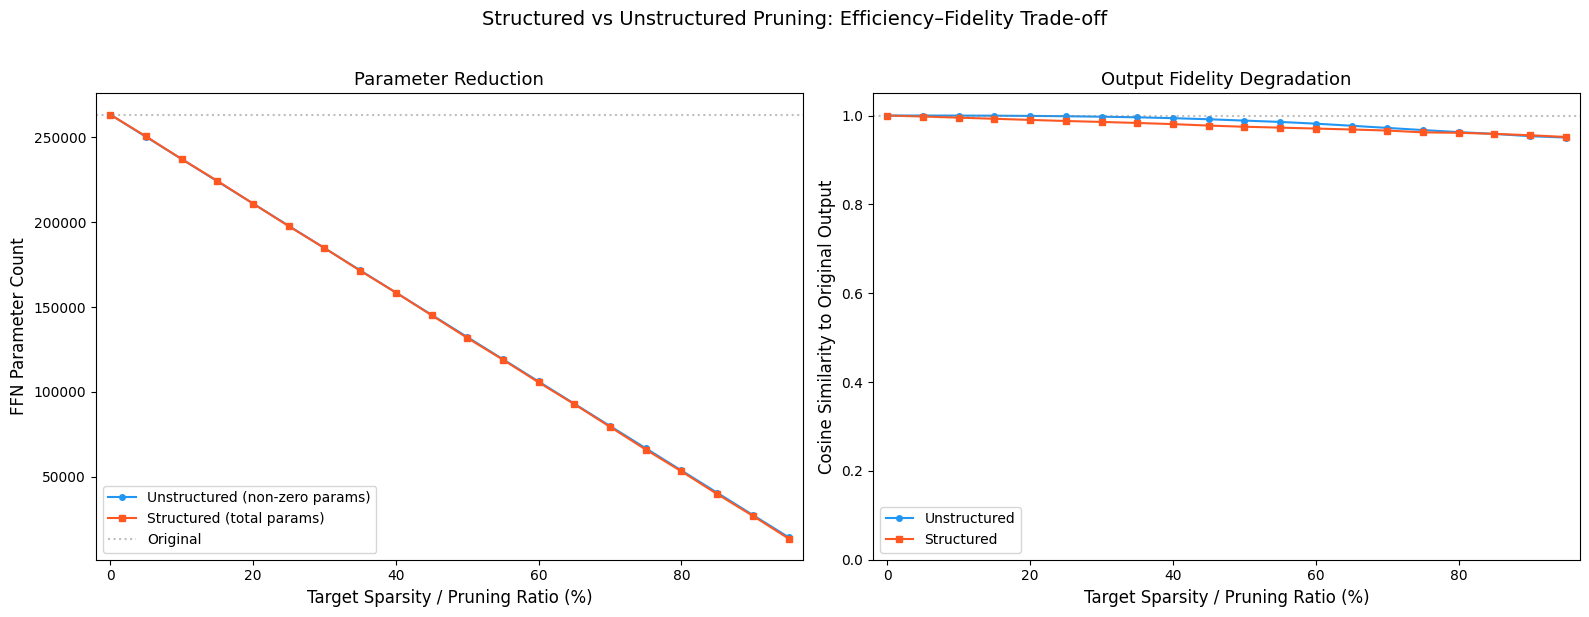

In [22]:
# Plot the comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sparsities_pct = [s * 100 for s in results["sparsity"]]

# Left: Parameter count vs sparsity
ax1.plot(
    sparsities_pct,
    results["unstruct_params"],
    "o-",
    color="#2196F3",
    label="Unstructured (non-zero params)",
    markersize=4,
)
ax1.plot(
    sparsities_pct,
    results["struct_params"],
    "s-",
    color="#FF5722",
    label="Structured (total params)",
    markersize=4,
)
ax1.axhline(total_ffn_params, color="gray", linestyle=":", alpha=0.5, label="Original")
ax1.set_xlabel("Target Sparsity / Pruning Ratio (%)", fontsize=12)
ax1.set_ylabel("FFN Parameter Count", fontsize=12)
ax1.set_title("Parameter Reduction", fontsize=13)
ax1.legend(fontsize=10)
ax1.set_xlim(-2, 97)

# Right: Output fidelity vs sparsity
ax2.plot(
    sparsities_pct,
    results["unstruct_cos"],
    "o-",
    color="#2196F3",
    label="Unstructured",
    markersize=4,
)
ax2.plot(
    sparsities_pct,
    results["struct_cos"],
    "s-",
    color="#FF5722",
    label="Structured",
    markersize=4,
)
ax2.axhline(1.0, color="gray", linestyle=":", alpha=0.5)
ax2.set_xlabel("Target Sparsity / Pruning Ratio (%)", fontsize=12)
ax2.set_ylabel("Cosine Similarity to Original Output", fontsize=12)
ax2.set_title("Output Fidelity Degradation", fontsize=13)
ax2.legend(fontsize=10)
ax2.set_xlim(-2, 97)
ax2.set_ylim(0, 1.05)

plt.suptitle(
    "Structured vs Unstructured Pruning: Efficiency–Fidelity Trade-off",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

# 5) Iterative Pruning vs One-Shot Pruning

**Intuition**

- **One-shot pruning** removes all target weights at once.
- **Iterative pruning** removes a small fraction at each step, optionally allowing the remaining weights to adjust (via fine-tuning) between rounds.
- The Lottery Ticket Hypothesis (Frankle & Carlin, 2019) showed that iteratively pruned networks can match the original's accuracy when reset to their initial weights.

Here we demonstrate the mechanical difference: iterative pruning applies the threshold progressively, which can lead to different final masks than one-shot because intermediate pruning changes the relative ordering of remaining weights.

In [18]:
def iterative_unstructured_pruning(weight, target_sparsity, num_steps):
    """
    Prune weights gradually over multiple steps.
    At each step, we prune a fraction of the REMAINING weights, reaching the
    target sparsity after all steps.

    The per-step sparsity is computed so that:
    (1 - per_step_sparsity)^num_steps = (1 - target_sparsity)
    i.e., the survival rates compound to the target.

    This differs from one-shot because after each pruning step, the magnitude
    ranking among SURVIVING weights may differ from the global ranking of the
    original weights.

    Args:
        weight: original weight tensor
        target_sparsity: final desired sparsity fraction
        num_steps: number of iterative pruning rounds
    Returns:
        cumulative_mask: final binary mask after all steps
        masks_per_step: list of masks at each step (for visualization)
    """
    # Compute per-step survival rate
    # survival^num_steps = (1 - target_sparsity)
    per_step_survival = (1 - target_sparsity) ** (1.0 / num_steps)
    per_step_sparsity = 1 - per_step_survival

    # Start with all weights active
    cumulative_mask = torch.ones_like(weight)
    current_weight = weight.clone()
    masks_per_step = []

    for step in range(num_steps):
        # Prune only among currently surviving weights
        # Zero out already-pruned weights so they don't affect threshold
        active_magnitudes = current_weight.abs() * cumulative_mask

        # Among non-zero (active) weights, find the magnitude threshold
        active_flat = active_magnitudes[cumulative_mask == 1].flatten()
        if active_flat.numel() == 0:
            break

        num_to_prune = int(per_step_sparsity * active_flat.numel())
        if num_to_prune == 0:
            masks_per_step.append(cumulative_mask.clone())
            continue

        threshold = active_flat.kthvalue(max(1, num_to_prune)).values.item()

        # Create step mask: prune active weights below threshold
        step_mask = ((active_magnitudes > threshold) | (cumulative_mask == 0)).float()

        # Update cumulative mask
        cumulative_mask = cumulative_mask * ((active_magnitudes > threshold).float())
        # Ensure already-pruned stay pruned
        cumulative_mask = (cumulative_mask > 0).float()

        masks_per_step.append(cumulative_mask.clone())
        current_weight = weight * cumulative_mask

    return cumulative_mask, masks_per_step

Target sparsity: 90%
One-shot actual sparsity: 89.9994%
Iterative actual sparsity: 89.9948%
Mask disagreements: 3 / 65,536 (0.00%)


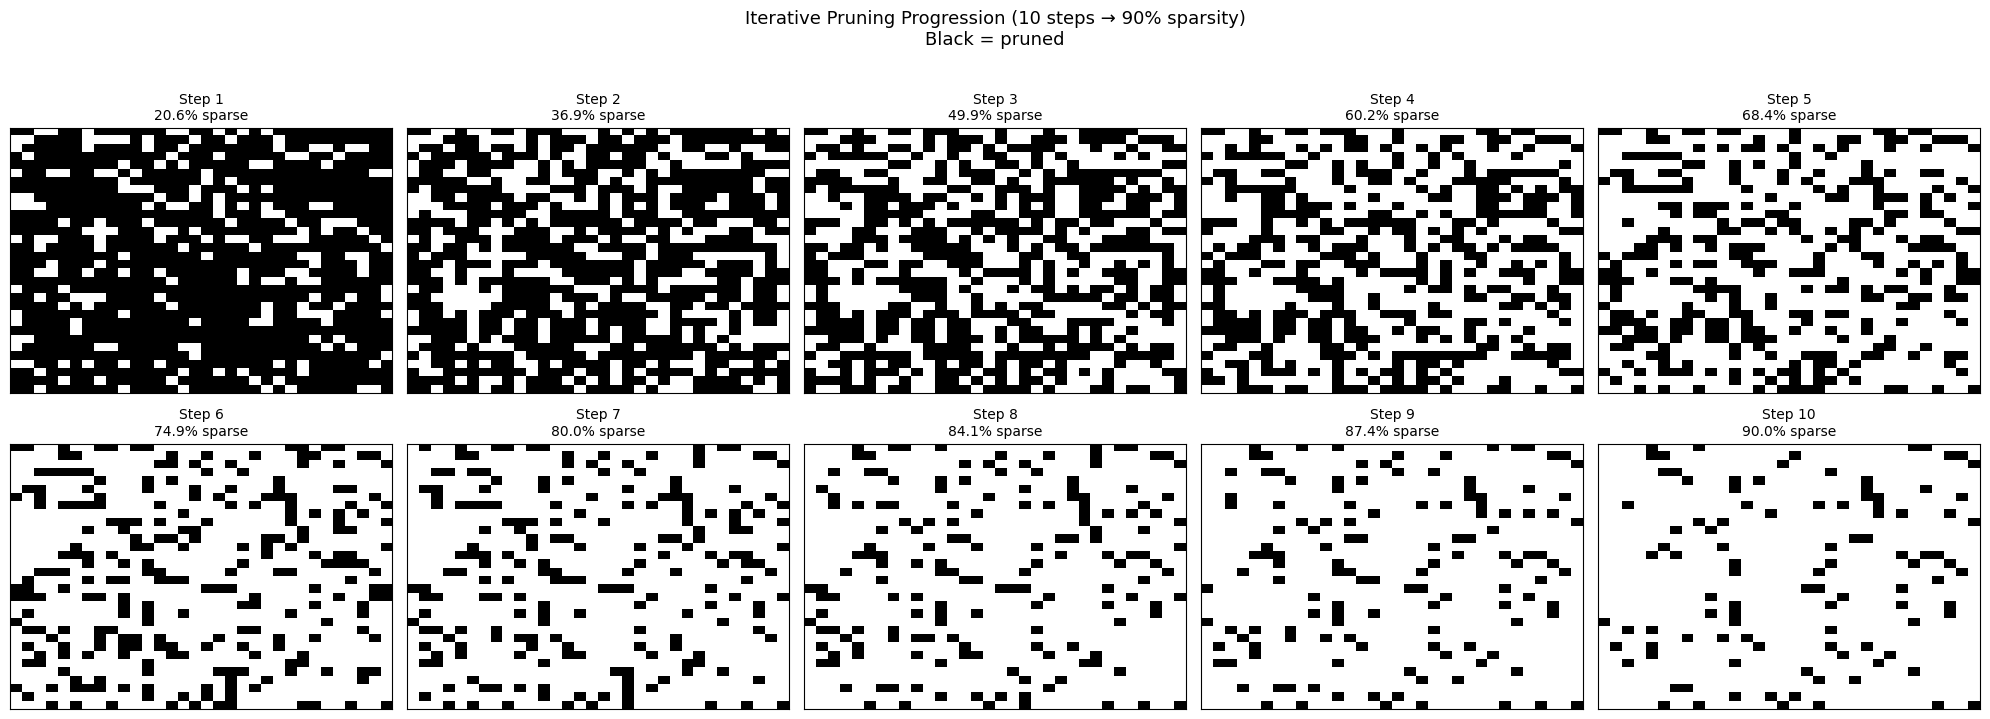

In [19]:
# Compare one-shot vs iterative at 90% sparsity
weight = model.ffn1_up.weight.data.clone()
target = 0.9

# One-shot: single global threshold
oneshot_mask = unstructured_magnitude_pruning(weight, target)

# Iterative: 10 progressive steps
iterative_mask, step_masks = iterative_unstructured_pruning(weight, target, num_steps=10)

# Compare the two approaches
oneshot_sparsity = 1.0 - oneshot_mask.sum().item() / oneshot_mask.numel()
iter_sparsity = 1.0 - iterative_mask.sum().item() / iterative_mask.numel()

# How many weights differ between the two final masks?
mask_diff = (oneshot_mask != iterative_mask).sum().item()
total_weights = oneshot_mask.numel()

print(f"Target sparsity: {target:.0%}")
print(f"One-shot actual sparsity: {oneshot_sparsity:.4%}")
print(f"Iterative actual sparsity: {iter_sparsity:.4%}")
print(f"Mask disagreements: {mask_diff:,} / {total_weights:,} ({mask_diff/total_weights:.2%})")

# Visualize the progression of iterative pruning
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
slice_r, slice_c = 32, 32

for idx, step_mask in enumerate(step_masks):
    row = idx // 5
    col = idx % 5
    mask_slice = step_mask[:slice_r, :slice_c].cpu().numpy()
    actual_sp = 1.0 - step_mask.sum().item() / step_mask.numel()

    axes[row, col].imshow(1 - mask_slice, cmap="gray", vmin=0, vmax=1, aspect="auto")
    axes[row, col].set_title(f"Step {idx+1}\n{actual_sp:.1%} sparse", fontsize=10)
    axes[row, col].set_xticks([])
    axes[row, col].set_yticks([])

plt.suptitle("Iterative Pruning Progression (10 steps → 90% sparsity)\nBlack = pruned", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary

## Decision Framework
| Scenario | Recommended Approach | Why |
|---|---|---|
| **Deploying on GPU/TPU with dense kernels** | Structured | Only structured pruning gives real speedup on standard hardware |
| **Deploying on sparse-capable hardware** (A100 sparse cores) | Unstructured | Higher compression with hardware-supported sparse ops |
| **Maximum compression, accuracy is critical** | Unstructured + fine-tuning | Unstructured preserves more information at the same parameter reduction |
| **Simple deployment, no custom inference** | Structured | Produces standard smaller model, no special runtime needed |
| **Research / Lottery Ticket exploration** | Iterative unstructured | Required by the LTH protocol |
| **Pruning attention heads** | Structured | Heads are natural structural units (Michel et al., 2019) |

## Key Takeaways
1. **Unstructured pruning** is finer-grained: it can achieve higher compression at the same accuracy cost, but requires sparse hardware/software to realize speedups.
2. **Structured pruning** is coarser but practical: it produces genuinely smaller dense models that run faster on any hardware.
3. **Global pruning** beats uniform pruning because it allocates the pruning budget according to each layer's natural importance.
4. **Coupled pruning** of adjacent layers is essential for structured pruning to maintain shape consistency.
5. The choice between structured and unstructured is ultimately a **hardware-software co-design** question, not purely an algorithmic one.